# Installing and Importing Libraries

In [58]:
!pip install streamlit pyngrok

In [59]:
# Employee salary prediction using adult.csv file
# Importing Libraries
import kagglehub
import os
import re
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.preprocessing import RobustScaler, MaxAbsScaler, Normalizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
import joblib
import streamlit as st
import os
import threading
import time
from pyngrok import ngrok
from sklearn.compose import ColumnTransformer

In [75]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [61]:
!ngrok authtoken 30H42VbebdfYJ2UzZ9BH9xrBf2f_6tWyvGuNRFyK92QpmaLR6

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


# Understanding the data

In [62]:
path = kagglehub.dataset_download("nltkdata/movie-review")
print("Path to dataset files:", path)
data = pd.read_csv(path + "/movie_review.csv")
data

Using Colab cache for faster access to the 'movie-review' dataset.
Path to dataset files: /kaggle/input/movie-review


,fold_id,cv_tag,html_id,sent_id,text,tag
0,0,cv000,29590,0,films adapted from comic books have had plenty...,pos
1,0,cv000,29590,1,"for starters , it was created by alan moore ( ...",pos
2,0,cv000,29590,2,to say moore and campbell thoroughly researche...,pos
3,0,cv000,29590,3,"the book ( or "" graphic novel , "" if you will ...",pos
4,0,cv000,29590,4,"in other words , don't dismiss this film becau...",pos
...,...,...,...,...,...,...
64715,9,cv999,14636,20,that lack of inspiration can be traced back to...,neg
64716,9,cv999,14636,21,like too many of the skits on the current inca...,neg
64717,9,cv999,14636,22,"after watching one of the "" roxbury "" skits on...",neg
64718,9,cv999,14636,23,"bump unsuspecting women , and . . . that's all .",neg


In [63]:
data.shape

(64720, 6)

In [64]:
data.tail()

,fold_id,cv_tag,html_id,sent_id,text,tag
64715,9,cv999,14636,20,that lack of inspiration can be traced back to...,neg
64716,9,cv999,14636,21,like too many of the skits on the current inca...,neg
64717,9,cv999,14636,22,"after watching one of the "" roxbury "" skits on...",neg
64718,9,cv999,14636,23,"bump unsuspecting women , and . . . that's all .",neg
64719,9,cv999,14636,24,"after watching _a_night_at_the_roxbury_ , you'...",neg


In [65]:
data.isna()

,fold_id,cv_tag,html_id,sent_id,text,tag
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
64715,False,False,False,False,False,False
64716,False,False,False,False,False,False
64717,False,False,False,False,False,False
64718,False,False,False,False,False,False


In [66]:
data.isna().sum()

,0
fold_id,0
cv_tag,0
html_id,0
sent_id,0
text,0
tag,0


In [67]:
data.value_counts('tag')

,count
tag,
pos,32937
neg,31783


# PreProcessing Data

In [68]:
x = data['text']
y = data['tag']
x

,text
0,films adapted from comic books have had plenty...
1,"for starters , it was created by alan moore ( ..."
2,to say moore and campbell thoroughly researche...
3,"the book ( or "" graphic novel , "" if you will ..."
4,"in other words , don't dismiss this film becau..."
...,...
64715,that lack of inspiration can be traced back to...
64716,like too many of the skits on the current inca...
64717,"after watching one of the "" roxbury "" skits on..."
64718,"bump unsuspecting women , and . . . that's all ."


In [69]:
dct = {'pos':1, 'neg':0}
y = y.map(dct)
y

,tag
0,1
1,1
2,1
3,1
4,1
...,...
64715,0
64716,0
64717,0
64718,0


In [70]:
data = pd.concat([x, y], axis = 1)
data

,text,tag
0,films adapted from comic books have had plenty...,1
1,"for starters , it was created by alan moore ( ...",1
2,to say moore and campbell thoroughly researche...,1
3,"the book ( or "" graphic novel , "" if you will ...",1
4,"in other words , don't dismiss this film becau...",1
...,...,...
64715,that lack of inspiration can be traced back to...,0
64716,like too many of the skits on the current inca...,0
64717,"after watching one of the "" roxbury "" skits on...",0
64718,"bump unsuspecting women , and . . . that's all .",0


In [71]:
data['cleaned_text'] = data['text'].str.lower()
data

,text,tag,cleaned_text
0,films adapted from comic books have had plenty...,1,films adapted from comic books have had plenty...
1,"for starters , it was created by alan moore ( ...",1,"for starters , it was created by alan moore ( ..."
2,to say moore and campbell thoroughly researche...,1,to say moore and campbell thoroughly researche...
3,"the book ( or "" graphic novel , "" if you will ...",1,"the book ( or "" graphic novel , "" if you will ..."
4,"in other words , don't dismiss this film becau...",1,"in other words , don't dismiss this film becau..."
...,...,...,...
64715,that lack of inspiration can be traced back to...,0,that lack of inspiration can be traced back to...
64716,like too many of the skits on the current inca...,0,like too many of the skits on the current inca...
64717,"after watching one of the "" roxbury "" skits on...",0,"after watching one of the "" roxbury "" skits on..."
64718,"bump unsuspecting women , and . . . that's all .",0,"bump unsuspecting women , and . . . that's all ."


In [72]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

data['cleaned_text'] = data['cleaned_text'].apply(clean_text)
data

,text,tag,cleaned_text
0,films adapted from comic books have had plenty...,1,films adapted from comic books have had plenty...
1,"for starters , it was created by alan moore ( ...",1,for starters it was created by alan moore an...
2,to say moore and campbell thoroughly researche...,1,to say moore and campbell thoroughly researche...
3,"the book ( or "" graphic novel , "" if you will ...",1,the book or graphic novel if you will is ...
4,"in other words , don't dismiss this film becau...",1,in other words dont dismiss this film because...
...,...,...,...
64715,that lack of inspiration can be traced back to...,0,that lack of inspiration can be traced back to...
64716,like too many of the skits on the current inca...,0,like too many of the skits on the current inca...
64717,"after watching one of the "" roxbury "" skits on...",0,after watching one of the roxbury skits on s...
64718,"bump unsuspecting women , and . . . that's all .",0,bump unsuspecting women and thats all


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=2000)

X = tfidf.fit_transform(data['cleaned_text']).toarray()

In [74]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# Initialize PCA to reduce dimensions, e.g., to 100 components or a specific variance explained
pca = PCA(n_components=0.95, svd_solver='full') # Retain 95% of variance, or specify an integer like 100

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features after PCA: {X_train_pca.shape[1]}")

Original number of features: 2000
Reduced number of features after PCA: 1650


#Model Comparison

## Models

In [76]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "LightGBM": LGBMClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

##GridSearchCV

In [77]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [78]:
print("Tuning Logistic Regression...")

param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200]
}

grid_search_lr = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid_lr, cv=kf, scoring='f1', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train_pca, y_train)

print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best F1-score for Logistic Regression: {grid_search_lr.best_score_:.4f}")
best_lr_model = grid_search_lr.best_estimator_
models["Logistic Regression"] = best_lr_model

Tuning Logistic Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Logistic Regression: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}
Best F1-score for Logistic Regression: 0.6443


## Running models

In [79]:
result = {}
xtrain = X_train_pca
xtest = X_test_pca
ytrain = y_train
ytest = y_test

for model_name, model in models.items():
    model.fit(xtrain, ytrain)
    prediction = model.predict(xtest)
    acc = accuracy_score(ytest, prediction)
    result[f"PCA_{model_name}"] = acc
    print(f"PCA_{model_name} : {acc}")
    print(classification_report(ytest, prediction))

PCA_Logistic Regression : 0.6374713049620343
              precision    recall  f1-score   support

           0       0.64      0.62      0.63     11142
           1       0.64      0.66      0.65     11510

    accuracy                           0.64     22652
   macro avg       0.64      0.64      0.64     22652
weighted avg       0.64      0.64      0.64     22652

PCA_KNN : 0.5031785272823591
              precision    recall  f1-score   support

           0       0.50      0.88      0.64     11142
           1       0.54      0.14      0.22     11510

    accuracy                           0.50     22652
   macro avg       0.52      0.51      0.43     22652
weighted avg       0.52      0.50      0.42     22652

[LightGBM] [Info] Number of positive: 21427, number of negative: 20641
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.273329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 420750
[Li

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PCA_LightGBM : 0.6109835776090411
              precision    recall  f1-score   support

           0       0.61      0.56      0.59     11142
           1       0.61      0.66      0.63     11510

    accuracy                           0.61     22652
   macro avg       0.61      0.61      0.61     22652
weighted avg       0.61      0.61      0.61     22652

PCA_Decision Tree : 0.5199099417269998
              precision    recall  f1-score   support

           0       0.51      0.52      0.52     11142
           1       0.53      0.52      0.52     11510

    accuracy                           0.52     22652
   macro avg       0.52      0.52      0.52     22652
weighted avg       0.52      0.52      0.52     22652

PCA_Random Forest : 0.565380540349638
              precision    recall  f1-score   support

           0       0.57      0.50      0.53     11142
           1       0.56      0.63      0.60     11510

    accuracy                           0.57     22652
   macro avg     

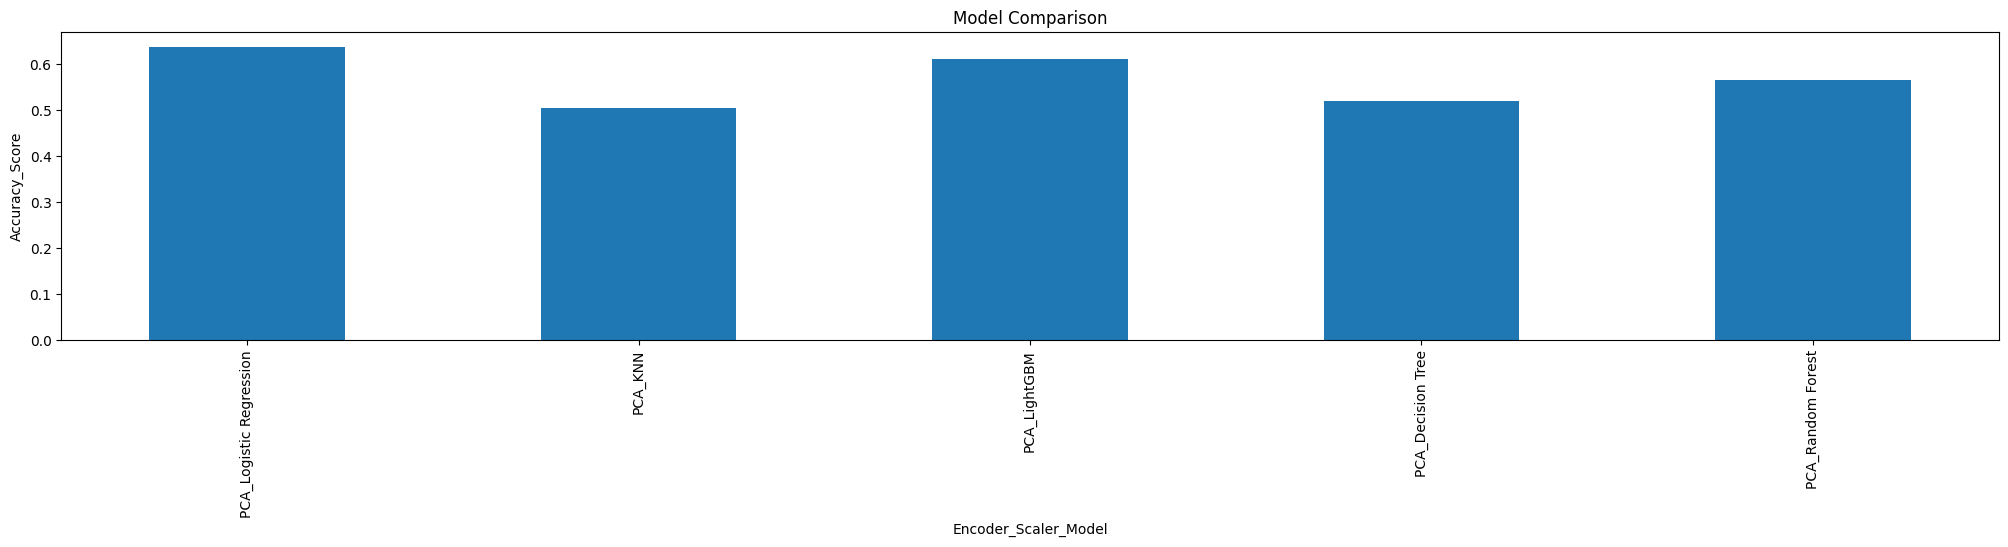

In [80]:
plt.figure(figsize=(25, 4))
plt.bar(result.keys(), result.values(), width = 0.5)
plt.xticks(rotation = 90)
plt.ylabel("Accuracy_Score")
plt.xlabel("Encoder_Scaler_Model")
plt.title("Model Comparison")
plt.show()

In [81]:
max_value = max(result.values())
max_keys = [key for key, value in result.items() if value == max_value]
print(max_keys, max_value, sep = "\n\n")

['PCA_Logistic Regression']

0.6374713049620343


In [82]:
from sklearn.cluster import KMeans
# Fit KMeans on the PCA-transformed training data for consistency with visualization
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_train_pca)

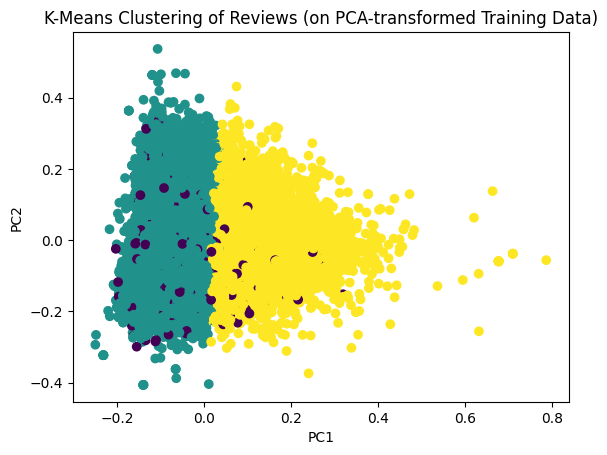

In [83]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=clusters, cmap='viridis')
plt.title("K-Means Clustering of Reviews (on PCA-transformed Training Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [94]:
model_name = max_keys[0]
original_model_name = model_name.replace('PCA_', '')
model = models[original_model_name]
joblib.dump(model, 'best_model_F1.pkl')
joblib.dump(tfidf, 'tfidf.pkl')
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(result, 'model_results.pkl') # Save the results dictionary
joblib.dump(X_train_pca, 'X_train_pca.pkl') # Save X_train_pca for visualization
joblib.dump(clusters, 'clusters.pkl') # Save clusters for visualization
joblib.dump(y_test, 'y_test.pkl') # Save y_test for confusion matrix
joblib.dump(data, 'data.pkl') # Save the full data for sentiment distribution

['data.pkl']

# Application

In [98]:
%%writefile app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd # Import pandas
import matplotlib.pyplot as plt # Import matplotlib for plotting
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Import for confusion matrix

# --- PAGE CONFIG ---
st.set_page_config(page_title="CineSense AI", page_icon="🎬", layout="wide")

# --- CUSTOM CSS FOR STYLING ---
st.markdown("""
    <style>
    .main {
        background-color: #f5f7f9;
    }
    .stButton>button {
        width: 100%;
        border-radius: 5px;
        height: 3em;
        background-color: #FF4B4B;
        color: white;
        font-weight: bold;
    }
    .sentiment-box {
        padding: 20px;
        border-radius: 10px;
        text-align: center;
        margin-bottom: 10px;
        color: white;
    }
    .pos-box { background-color: #28a745; }
    .neg-box { background-color: #dc3545; }
    </style>
    """, unsafe_allow_html=True)

# --- LOAD MODELS ---
@st.cache_resource
def load_assets():
    try:
        tfidf = joblib.load("/content/tfidf.pkl")
        model = joblib.load("/content/best_model_F1.pkl")
        kmeans = joblib.load("/content/kmeans.pkl")
        pca = joblib.load("/content/pca.pkl")
        X_train_pca = joblib.load("/content/X_train_pca.pkl") # Load X_train_pca
        clusters = joblib.load("/content/clusters.pkl") # Load clusters
        y_test = joblib.load("/content/y_test.pkl") # Load y_test
        data = joblib.load("/content/data.pkl") # Load the full data

        try:
            all_model_results = joblib.load("/content/model_results.pkl")
            model_accuracies = {k.replace('PCA_', ''): v for k, v in all_model_results.items()}
        except:
            model_accuracies = {"LR": 0.63, "KNN": 0.50, "LGBM": 0.61, "RF": 0.57}

        return tfidf, model, kmeans, pca, X_train_pca, clusters, y_test, data, model_accuracies
    except Exception as e:
        st.error(f"Error loading assets: {e}")
        return None, None, None, None, None, None, None, None, {}

tfidf, model, kmeans, pca, X_train_pca, clusters, y_test, data, model_accuracies = load_assets()

# --- HELPER FUNCTIONS ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# --- SIDEBAR ---
with st.sidebar:
    st.image("https://img.icons8.com/fluency/144/movie-projector.png", width=100)
    st.title("Movie Review Analyzer")
    st.info("This AI analyzes movie reviews using NLP, PCA dimensionality reduction, and K-Means clustering.")
    st.markdown("---")
    st.subheader("Model Metrics")
    # Convert to DataFrame before displaying to handle column names
    accuracies_df = pd.DataFrame(list(model_accuracies.items()), columns=["Model", "Accuracy"])
    st.dataframe(accuracies_df, use_container_width=True)

    st.markdown("---")
    st.subheader("Overall Sentiment Distribution")
    if data is not None:
        sentiment_counts = data['tag'].value_counts().rename(index={1: 'Positive', 0: 'Negative'})
        fig_sentiment, ax_sentiment = plt.subplots()
        ax_sentiment.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])
        ax_sentiment.set_title('Distribution of Sentiments in Dataset')
        ax_sentiment.set_xlabel('Sentiment')
        ax_sentiment.set_ylabel('Number of Reviews')
        st.pyplot(fig_sentiment)
        plt.close(fig_sentiment)
    else:
        st.warning("Data for sentiment distribution not loaded.")

# --- MAIN UI ---
st.title("🎬 Movie Review Analyzer")
st.markdown("Experience high-fidelity sentiment analysis and behavioral clustering.")

col1, col2 = st.columns([2, 1])

with col1:
    user_input = st.text_area("✍️ Paste your review here:", height=200, placeholder="The cinematography was breathtaking, but the plot was thin...")
    analyze_btn = st.button("Run Intelligence Engine")

with col2:
    st.subheader("Analysis Results")
    if analyze_btn and user_input.strip() != "":
        # Process
        clean = clean_text(user_input)
        vector = tfidf.transform([clean])
        vector_pca = pca.transform(vector)

        prediction = model.predict(vector_pca)[0]
        cluster = kmeans.predict(vector_pca)[0]

        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(vector_pca)[0]

        # Display Sentiment
        if prediction == 1:
            st.markdown('<div class="sentiment-box pos-box"><h3>POSITIVE SENTIMENT</h3></div>', unsafe_allow_html=True)
        else:
            st.markdown('<div class="sentiment-box neg-box"><h3>NEGATIVE SENTIMENT</h3></div>', unsafe_allow_html=True)

        # Display Cluster Metrics
        cluster_labels = {0: "Harsh Critics", 1: "Emotional Fans", 2: "Neutral Reviewers"}
        c_name = cluster_labels.get(cluster, "Unknown")
        st.metric(label="Reviewer Persona", value=c_name)

        # Confidence Scores
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(vector_pca)[0]
            st.write("**Confidence Level:**")
            st.progress(float(proba[1]))
            st.caption(f"Confidence: {max(proba)*100:.1f}%")

        st.subheader("Cluster Visualization")
        if X_train_pca is not None and clusters is not None:
            fig, ax = plt.subplots(figsize=(8, 6))
            scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=5)
            ax.scatter(vector_pca[:, 0], vector_pca[:, 1], color='red', marker='X', s=200, label='Current Review', edgecolor='black')
            ax.set_title("K-Means Clusters with Current Review Highlighted")
            ax.set_xlabel("Principal Component 1")
            ax.set_ylabel("Principal Component 2")
            ax.legend()
            st.pyplot(fig)
            plt.close(fig) # Close the figure to prevent it from displaying again
        else:
            st.warning("Training data for cluster visualization not loaded.")

    else:
        st.write("Results will appear here after analysis.")

# --- FOOTER VISUALS ---
st.markdown("---")
st.subheader("Model Performance Benchmarks")
st.bar_chart(model_accuracies)

st.markdown("---")
st.subheader("Confusion Matrix for Best Model")
if model is not None and pca is not None and y_test is not None:
    # Predict on the test set to get predictions for the confusion matrix
    X_test_pca = pca.transform(tfidf.transform(data['cleaned_text'].loc[y_test.index]).toarray()) # Ensure X_test_pca is correctly derived from y_test indices
    y_pred = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    fig_cm, ax_cm = plt.subplots()
    disp.plot(cmap='Blues', ax=ax_cm)
    ax_cm.set_title('Confusion Matrix')
    st.pyplot(fig_cm)
    plt.close(fig_cm)
else:
    st.warning("Model, PCA, or y_test not loaded for confusion matrix.")

Overwriting app.py


In [96]:
def run_streamlit():
    os.system('streamlit run app.py --server.port 8501')

# Kill any existing ngrok tunnels before starting a new one
ngrok.kill()

thread = threading.Thread(target = run_streamlit)
thread.start()

time.sleep(5)
public_url = ngrok.connect(8501)
print("Streamlit Application running at:", public_url)
print("Please re-run the positive sample from the dataset in the Streamlit app and share the console output.")

Streamlit Application running at: NgrokTunnel: "https://54eb-35-185-82-111.ngrok-free.app" -> "http://localhost:8501"
Please re-run the positive sample from the dataset in the Streamlit app and share the console output.
